In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pickle
import warnings
warnings.filterwarnings('ignore')

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")


All libraries imported successfully!


## 1. Data Loading

Let's load and examine the student performance dataset.

In [2]:
# Load the dataset
data = pd.read_csv('../Dataset/StudentPerformanceFactors.csv')

# Display basic information
print("Dataset Shape:", data.shape)
print("\nFirst Few Rows:")
print(data.head())
print("\nDataset Info:")
print(data.info())
print("\nMissing Values:")
print(data.isnull().sum())
print("\nBasic Statistics:")
print(data.describe())

Dataset Shape: (6607, 20)

First Few Rows:
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family

## 2. Data Preprocessing

### 2.1 Handle Missing Values

In [3]:
# Check for missing values
print("Missing values before preprocessing:")
print(data.isnull().sum())

# Fill missing numerical values with median
numerical_cols = data.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if data[col].isnull().sum() > 0:
        data[col].fillna(data[col].median(), inplace=True)

# Fill missing categorical values with mode
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if data[col].isnull().sum() > 0:
        data[col].fillna(data[col].mode()[0], inplace=True)

print("\nMissing values after preprocessing:")
print(data.isnull().sum().sum())  # Should be 0

Missing values before preprocessing:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Missing values after preprocessing:
0


### 2.2 Remove Duplicates

In [4]:
# Check for duplicates
print(f"Duplicate rows before removal: {data.duplicated().sum()}")

# Remove duplicate rows
data.drop_duplicates(inplace=True)

print(f"Duplicate rows after removal: {data.duplicated().sum()}")
print(f"Dataset shape after removing duplicates: {data.shape}")

Duplicate rows before removal: 0
Duplicate rows after removal: 0
Dataset shape after removing duplicates: (6607, 20)


### 2.3 Feature Selection and Encoding

In [5]:
# Create a copy for preprocessing
df = data.copy()

# Identify target variable
target = 'Exam_Score'
print(f"Target variable: {target}")

# Encode categorical variables using LabelEncoder
label_encoders = {}
categorical_features = df.select_dtypes(include=['object']).columns

print(f"\nCategorical features to encode: {list(categorical_features)}")

for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("\nEncoding completed successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows after encoding:")
print(df.head())

Target variable: Exam_Score

Categorical features to encode: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Encoding completed successfully!

Dataset shape: (6607, 20)

First few rows after encoding:
   Hours_Studied  Attendance  Parental_Involvement  Access_to_Resources  \
0             23          84                     1                    0   
1             19          64                     1                    2   
2             24          98                     2                    2   
3             29          89                     1                    2   
4             19          92                     2                    2   

   Extracurricular_Activities  Sleep_Hours  Previous_Scores  Motivation_Level  \
0                           0            7 

## 3. Exploratory Data Analysis (EDA)

### 3.1 Study Hours vs Final Score

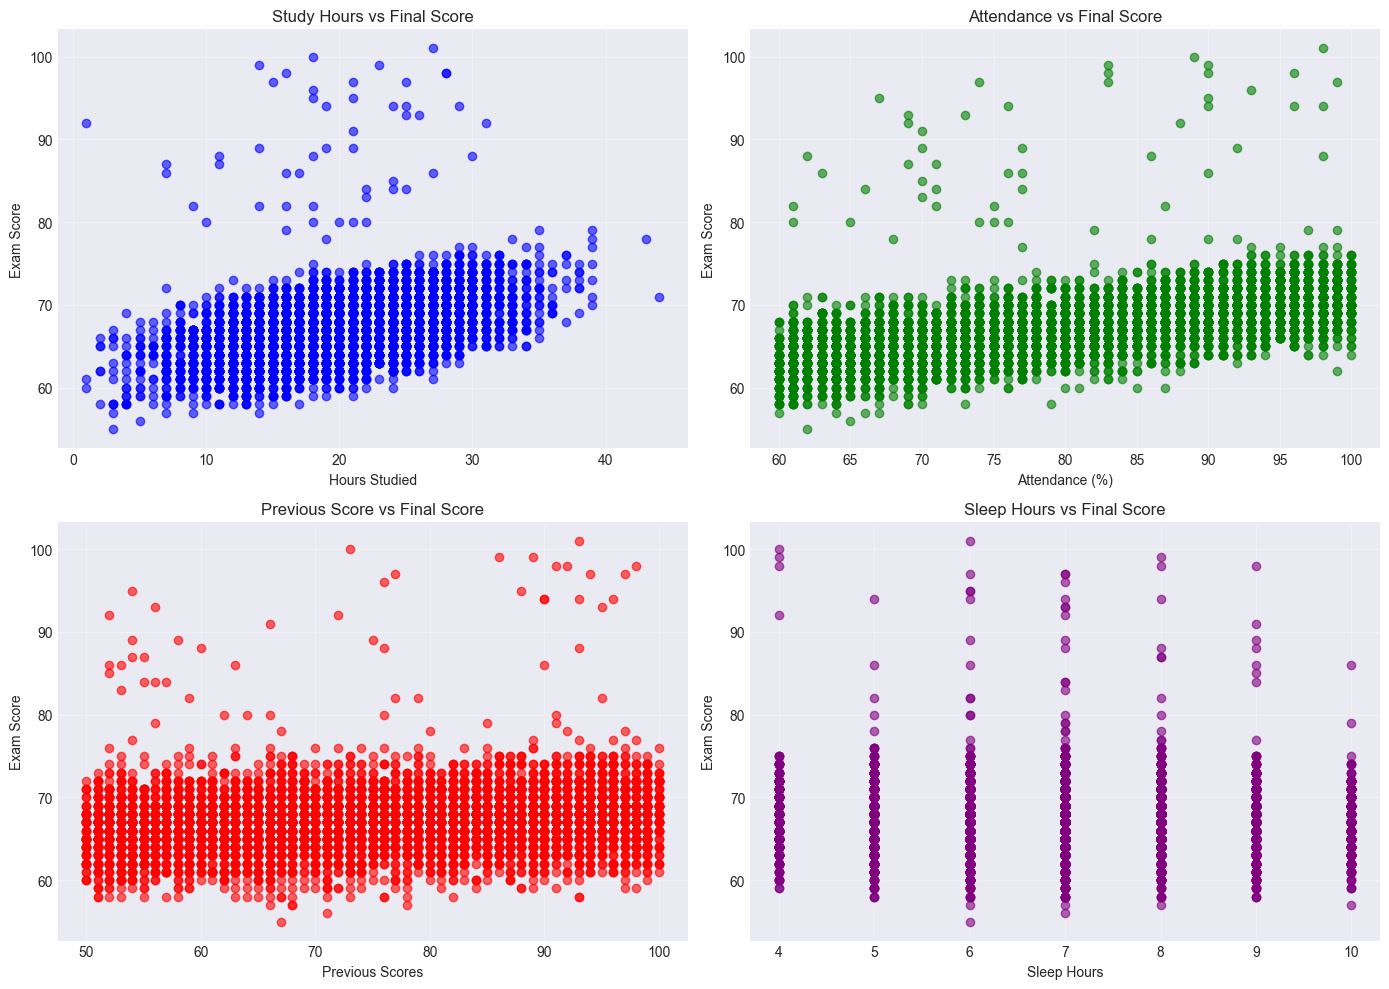

Scatter plot visualizations created successfully!


In [6]:
# Create a figure with multiple visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Study Hours vs Final Score
axes[0, 0].scatter(data['Hours_Studied'], data['Exam_Score'], alpha=0.6, color='blue')
axes[0, 0].set_xlabel('Hours Studied')
axes[0, 0].set_ylabel('Exam Score')
axes[0, 0].set_title('Study Hours vs Final Score')
axes[0, 0].grid(True, alpha=0.3)

# Attendance vs Final Score
axes[0, 1].scatter(data['Attendance'], data['Exam_Score'], alpha=0.6, color='green')
axes[0, 1].set_xlabel('Attendance (%)')
axes[0, 1].set_ylabel('Exam Score')
axes[0, 1].set_title('Attendance vs Final Score')
axes[0, 1].grid(True, alpha=0.3)

# Previous Score vs Final Score
axes[1, 0].scatter(data['Previous_Scores'], data['Exam_Score'], alpha=0.6, color='red')
axes[1, 0].set_xlabel('Previous Scores')
axes[1, 0].set_ylabel('Exam Score')
axes[1, 0].set_title('Previous Score vs Final Score')
axes[1, 0].grid(True, alpha=0.3)

# Sleep Hours vs Final Score
axes[1, 1].scatter(data['Sleep_Hours'], data['Exam_Score'], alpha=0.6, color='purple')
axes[1, 1].set_xlabel('Sleep Hours')
axes[1, 1].set_ylabel('Exam Score')
axes[1, 1].set_title('Sleep Hours vs Final Score')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Scatter plot visualizations created successfully!")

### 3.2 Correlation Heatmap

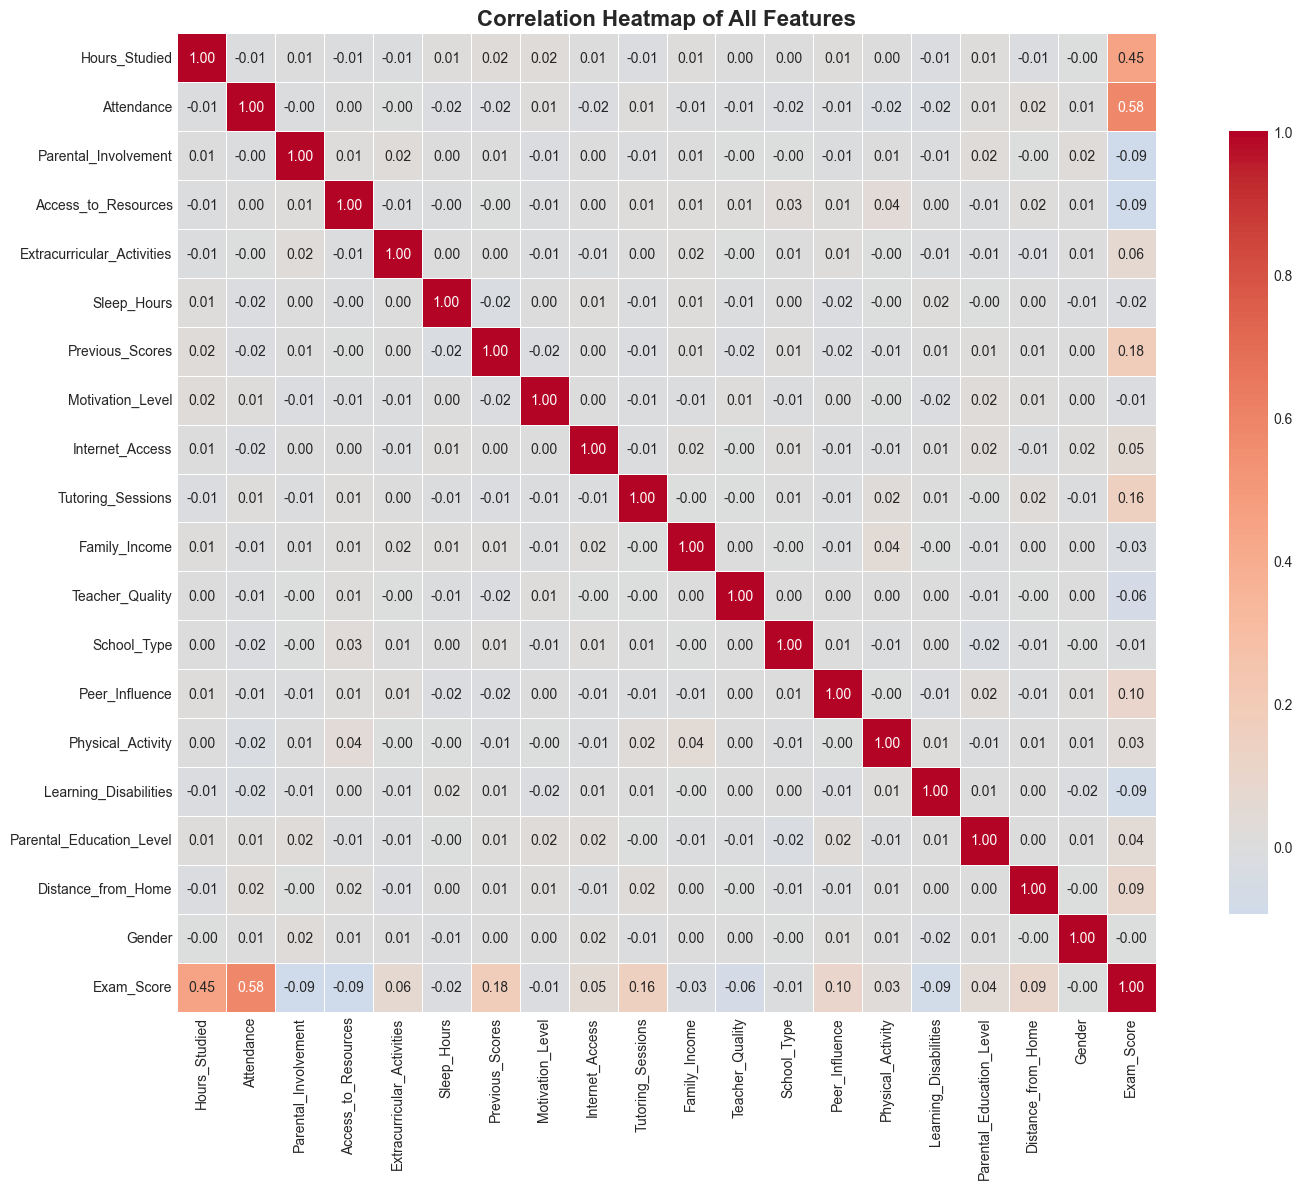


Top 10 Features correlated with Exam Score (Target):
Attendance                    0.581072
Hours_Studied                 0.445455
Previous_Scores               0.175079
Tutoring_Sessions             0.156525
Peer_Influence                0.100217
Distance_from_Home            0.088934
Extracurricular_Activities    0.064382
Internet_Access               0.051475
Parental_Education_Level      0.044574
Physical_Activity             0.027824
Name: Exam_Score, dtype: float64


In [7]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Create a large figure for the heatmap
plt.figure(figsize=(16, 12))

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Correlation Heatmap of All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with target variable
print("\nTop 10 Features correlated with Exam Score (Target):")
target_corr = correlation_matrix['Exam_Score'].sort_values(ascending=False)
print(target_corr[1:11])

## 4. Machine Learning Model Training

### 4.1 Prepare Data for Modeling

In [8]:
# Separate features (X) and target (y)
X = df.drop(columns=['Exam_Score'])
y = df['Exam_Score']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully!")
print(f"Training set (scaled) shape: {X_train_scaled.shape}")
print(f"Testing set (scaled) shape: {X_test_scaled.shape}")

# Save the scaler for later use in the Streamlit app
import os
model_dir = '../model'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

with open(f'{model_dir}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\nScaler saved successfully!")

Features shape: (6607, 19)
Target shape: (6607,)

Training set size: (5285, 19)
Testing set size: (1322, 19)

Features scaled successfully!
Training set (scaled) shape: (5285, 19)
Testing set (scaled) shape: (1322, 19)

Scaler saved successfully!


### 4.2 Train Linear Regression Model

In [9]:
# Train Linear Regression Model
print("Training Linear Regression Model...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression Model trained successfully!")
print(f"\nModel Coefficients: {lr_model.coef_[:5]}...")  # Show first 5 coefficients
print(f"Model Intercept: {lr_model.intercept_:.2f}")

Training Linear Regression Model...
Linear Regression Model trained successfully!

Model Coefficients: [ 1.72965085  2.27844739 -0.38674431 -0.35215528  0.27896614]...
Model Intercept: 67.22


### 4.3 Train Random Forest Model

In [10]:
# Train Random Forest Model
print("Training Random Forest Model (this may take a moment)...")
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Model trained successfully!")
print(f"\nNumber of trees: {rf_model.n_estimators}")
print(f"Max depth: {rf_model.max_depth}")

Training Random Forest Model (this may take a moment)...
Random Forest Model trained successfully!

Number of trees: 100
Max depth: 20


## 5. Model Evaluation

### 5.1 Evaluation Metrics

In [11]:
# Function to evaluate models
def evaluate_model(y_true, y_pred, model_name):
    """
    Evaluate model performance using multiple metrics.
    
    Parameters:
    - y_true: Actual values
    - y_pred: Predicted values
    - model_name: Name of the model for display
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"{model_name} Performance Metrics")
    print(f"{'='*50}")
    print(f"Mean Squared Error (MSE):    {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE):   {mae:.4f}")
    print(f"R² Score:                    {r2:.4f}")
    print(f"{'='*50}")
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Evaluate Linear Regression
lr_metrics = evaluate_model(y_test, y_pred_lr, "Linear Regression")

# Evaluate Random Forest
rf_metrics = evaluate_model(y_test, y_pred_rf, "Random Forest")

# Compare models
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"{'Metric':<20} {'Linear Regression':<20} {'Random Forest':<20}")
print("-"*60)
print(f"{'MSE':<20} {lr_metrics['MSE']:<20.4f} {rf_metrics['MSE']:<20.4f}")
print(f"{'RMSE':<20} {lr_metrics['RMSE']:<20.4f} {rf_metrics['RMSE']:<20.4f}")
print(f"{'MAE':<20} {lr_metrics['MAE']:<20.4f} {rf_metrics['MAE']:<20.4f}")
print(f"{'R² Score':<20} {lr_metrics['R2']:<20.4f} {rf_metrics['R2']:<20.4f}")
print("="*60)

# Determine best model
best_model_name = "Random Forest" if rf_metrics['R2'] > lr_metrics['R2'] else "Linear Regression"
print(f"\n✓ Best Model: {best_model_name} (based on R² score)")


Linear Regression Performance Metrics
Mean Squared Error (MSE):    4.3993
Root Mean Squared Error (RMSE): 2.0974
Mean Absolute Error (MAE):   1.0155
R² Score:                    0.6888

Random Forest Performance Metrics
Mean Squared Error (MSE):    4.6553
Root Mean Squared Error (RMSE): 2.1576
Mean Absolute Error (MAE):   1.0992
R² Score:                    0.6707

MODEL COMPARISON
Metric               Linear Regression    Random Forest       
------------------------------------------------------------
MSE                  4.3993               4.6553              
RMSE                 2.0974               2.1576              
MAE                  1.0155               1.0992              
R² Score             0.6888               0.6707              

✓ Best Model: Linear Regression (based on R² score)


### 5.2 Prediction Visualization

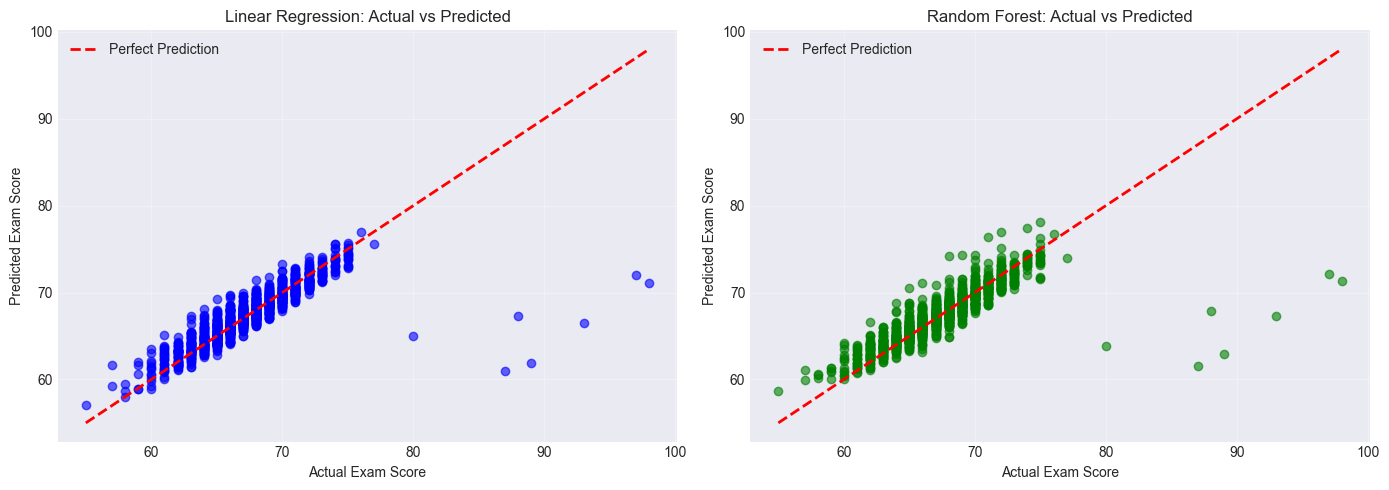

Prediction visualization completed!


In [12]:
# Visualize predictions vs actual values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Exam Score')
axes[0].set_ylabel('Predicted Exam Score')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Exam Score')
axes[1].set_ylabel('Predicted Exam Score')
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Prediction visualization completed!")

## 6. Save Trained Models

Save all trained models and preprocessing objects for use in the Streamlit app.

In [13]:
# Save Linear Regression Model
with open(f'{model_dir}/linear_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("✓ Linear Regression Model saved: linear_regression_model.pkl")

# Save Random Forest Model
with open(f'{model_dir}/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("✓ Random Forest Model saved: random_forest_model.pkl")

# Save label encoders
with open(f'{model_dir}/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("✓ Label Encoders saved: label_encoders.pkl")

# Save feature names for reference
with open(f'{model_dir}/feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)
print("✓ Feature Names saved: feature_names.pkl")

# Create a summary file
summary_text = f"""
MODEL TRAINING SUMMARY
======================

Dataset Information:
- Total samples: {len(df)}
- Number of features: {X.shape[1]}
- Target variable: Exam_Score

Data Split:
- Training set: {len(X_train)} samples
- Testing set: {len(X_test)} samples
- Test size ratio: 20%

Models Trained:
1. Linear Regression
   - MSE: {lr_metrics['MSE']:.4f}
   - RMSE: {lr_metrics['RMSE']:.4f}
   - MAE: {lr_metrics['MAE']:.4f}
   - R² Score: {lr_metrics['R2']:.4f}

2. Random Forest Regressor
   - MSE: {rf_metrics['MSE']:.4f}
   - RMSE: {rf_metrics['RMSE']:.4f}
   - MAE: {rf_metrics['MAE']:.4f}
   - R² Score: {rf_metrics['R2']:.4f}

Best Model: {best_model_name}

Files Generated:
- linear_regression_model.pkl
- random_forest_model.pkl
- scaler.pkl
- label_encoders.pkl
- feature_names.pkl

Date: {pd.Timestamp.now()}
"""

with open(f'{model_dir}/training_summary.txt', 'w') as f:
    f.write(summary_text)
print("\n✓ Training summary saved: training_summary.txt")

print("\n" + "="*50)
print("ALL MODELS SAVED SUCCESSFULLY!")
print("="*50)

✓ Linear Regression Model saved: linear_regression_model.pkl
✓ Random Forest Model saved: random_forest_model.pkl
✓ Label Encoders saved: label_encoders.pkl
✓ Feature Names saved: feature_names.pkl

✓ Training summary saved: training_summary.txt

ALL MODELS SAVED SUCCESSFULLY!
